# exp_02 PLIP zero-shot — external OOD evaluation (Chaoyang + LungHist700)

Extends the LC25000 PLIP zero-shot pattern (`CLIP_PLIP_zeroshot.ipynb`) to two
license-gated external datasets used elsewhere in `exp_07_ood_eval`:

- **Chaoyang** — different-hospital colon (Zhu et al., 2021). Restricted
  argmax over the 2 LC25000 colon classes (`benign colon tissue`,
  `colon adenocarcinoma`); `serrated` and `adenoma` are excluded from scoring.
- **LungHist700 (20x subset)** — different-organ lung (Diosdado et al.,
  2024). Restricted argmax over the 3 LC25000 lung classes (`benign lung
  tissue`, `lung adenocarcinoma`, `lung squamous cell carcinoma`).

A single `DATASET` switch (Cell 2) selects which dataset is loaded; everything
downstream (PLIP loading, prompt embedding, image embedding, restricted
argmax, metrics, UMAP) is shared.

## Model

PLIP (`vinid/plip`) loaded as a HuggingFace `TFCLIPModel` so the entire
notebook runs in the same TensorFlow / Keras environment as the rest of
`exp_07_ood_eval`. PLIP's **own** vision and text encoders are used — no
projection heads are trained, no checkpoints are loaded. The NHWC → NCHW
transpose required by `TFCLIPVisionModel` (HF mirrors the PyTorch convention)
is applied inside `encode_images`, matching the `plip_bert_composed` pattern
from `exp_08_plip_backbone`.

## Outputs

For each dataset, three artifacts are written to the shared `exp_07_ood_eval`
results bundle (so this notebook's outputs sit alongside the trained-variant
OOD metrics):

- `results/metrics/exp_07_ood_eval/plip_zeroshot_<dataset_tag>_ood_classification.json`
- `results/plots/exp_07_ood_eval/plip_zeroshot_<dataset_tag>_ood_cm.png`
- `results/plots/exp_07_ood_eval/plip_zeroshot_<dataset_tag>_ood_umap_grid.png`

where `<dataset_tag>` is one of `chaoyang` or `lunghist700_20x`.

## Setup

The two datasets are license-gated and must be uploaded manually to Drive
(same locations as the rest of `exp_07_ood_eval`); see Cell 3 for the
dataset-specific instructions — the notebook fails loudly with a fix-it
message if the dataset is missing.


## 0 — Bootstrap

In [1]:
# --- Cell 0: bootstrap ---
import os, sys, subprocess
os.environ["KERAS_BACKEND"] = "tensorflow"

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
BRANCH   = "main"
IN_COLAB = "google.colab" in sys.modules


def _clone_with_fallback(branch):
    try:
        subprocess.run(
            ["git", "clone", "-b", branch, REPO_URL, REPO_DIR],
            check=True, capture_output=True,
        )
        print(f"Cloned branch {branch!r}")
        return branch
    except subprocess.CalledProcessError:
        print(f"Branch {branch!r} not found; cloning main")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
        return "main"


if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        active = _clone_with_fallback(BRANCH)
    else:
        fetch = subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], capture_output=True)
        if fetch.returncode == 0:
            subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{BRANCH}"], check=True)
            active = BRANCH
        else:
            subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "checkout", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)
            active = "main"
    print(f"Active branch: {active}")
    subprocess.run([
        "pip", "install", "-q",
        "tensorflow==2.18.0", "keras==3.7.0",
        "transformers==4.46.0", "umap-learn", "kagglehub",
        "scikit-learn", "matplotlib", "pandas", "Pillow",
    ], check=True)
    subprocess.run(["pip", "uninstall", "-y", "-q", "jax", "jaxlib"], check=False)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])
print("KERAS_BACKEND:", os.environ.get("KERAS_BACKEND"))


Cloned branch 'main'
Active branch: main
Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab
KERAS_BACKEND: tensorflow


## 1 — Imports

In [2]:
# --- Cell 1: imports ---
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import json
import re
import subprocess
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras

from transformers import CLIPProcessor, TFCLIPModel

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
)
import umap

from src.utils.paths import is_colab, repo_root, drive_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import (
    CLASS_INFO, NUM_CLASSES, CLASS_NAMES, INDEX_TO_NAME, ID_TO_INDEX,
    discover_records, stratified_split, save_split, load_split,
)
from src.prompts.templates import baseline_prompt


## 2 — Configuration (DATASET switch lives here)

Toggle `DATASET` and re-run from Cell 1 onwards. All downstream cells are
dataset-agnostic; only Cell 3 (locator) and Cell 4 (label parsing) branch
on the value.

In [3]:
# --- Cell 2: config ---
EXPERIMENT = "exp_07_ood_eval"   # outputs co-locate with the OOD eval bundle
VERSION    = "plip_zeroshot"     # filename prefix; matches exp_02 zero-shot artifacts

# --- DATASET SWITCH (toggle and re-run from Cell 1 onwards) ---
# One of: "chaoyang", "lunghist700_20x"
DATASET = "chaoyang"

assert DATASET in {"chaoyang", "lunghist700_20x"}, (
    f"Unknown DATASET {DATASET!r}; pick one of: chaoyang, lunghist700_20x"
)

SEED = 42
set_global_seed(SEED)
enable_op_determinism()

IMG_SIZE   = 224
BATCH_SIZE = 32

# --- PLIP weights + processor ---
PLIP_MODEL_ID = "vinid/plip"
# PLIP shares OpenAI CLIP's image-normalisation constants; processor will apply them.

# --- Dataset-specific LC25000 mapping for restricted argmax ---
if DATASET == "chaoyang":
    DATASET_TAG     = "chaoyang"
    OOD_LABEL       = "Chaoyang"
    TARGET_LC_NAMES = [
        "benign colon tissue",
        "colon adenocarcinoma",
    ]
elif DATASET == "lunghist700_20x":
    DATASET_TAG     = "lunghist700_20x"
    OOD_LABEL       = "LungHist700 20x"
    TARGET_LC_NAMES = [
        "benign lung tissue",
        "lung adenocarcinoma",
        "lung squamous cell carcinoma",
    ]

TARGET_LC_IDX = sorted({
    ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == n)]
    for n in TARGET_LC_NAMES
})

# Output directories — co-located with exp_07 OOD eval artifacts.
METRICS_DIR = results_dir("metrics") / EXPERIMENT
CM_DIR      = results_dir("confusion_matrices") / EXPERIMENT
PLOTS_DIR   = results_dir("plots") / EXPERIMENT
for d in (METRICS_DIR, CM_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

OUT_TAG = f"{VERSION}_{DATASET_TAG}"   # e.g. plip_zeroshot_chaoyang

print(f"Dataset:        {DATASET}  (tag: {DATASET_TAG})")
print(f"PLIP model:     {PLIP_MODEL_ID}")
print(f"Target classes: {TARGET_LC_NAMES}")
print(f"               -> LC25000 indices {TARGET_LC_IDX}")
print(f"Metrics out:    {METRICS_DIR}/{OUT_TAG}_ood_classification.json")
print(f"Plots out:      {PLOTS_DIR}/{OUT_TAG}_ood_(cm|umap_grid).png")


Dataset:        chaoyang  (tag: chaoyang)
PLIP model:     vinid/plip
Target classes: ['benign colon tissue', 'colon adenocarcinoma']
               -> LC25000 indices [3, 4]
Metrics out:    /content/histopathology-clip-lab/results/metrics/exp_07_ood_eval/plip_zeroshot_chaoyang_ood_classification.json
Plots out:      /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plip_zeroshot_chaoyang_ood_(cm|umap_grid).png


## 3 — Locate dataset on Drive (DATASET-gated)

Both datasets are license-gated. The Chaoyang branch expects a
`chaoyang-data*.zip` (or pre-extracted tree) at
`/content/drive/MyDrive/TFM/datasets/Chaoyang/`; the LungHist700 branch
expects `LungHist700.rar` (or pre-extracted tree) at
`/content/drive/MyDrive/TFM/datasets/LungHist700/`. See the existing
`Chaoyang_OOD_eval.ipynb` / `LungHist700_OOD_eval.ipynb` notebooks for the
download workflow — this cell mirrors theirs.

In [4]:
# --- Cell 3: locate dataset on Drive ---
# Mirrors the locator cells from experiments/exp_07_ood_eval/{Chaoyang,LungHist700}_OOD_eval.ipynb.
# Both follow the same "archive-on-Drive then extract once" pattern; the rar/zip and
# search-directory differ by dataset.


def _has_images(d: Path) -> bool:
    if not d.exists():
        return False
    return any(True for _ in d.rglob("*.jpg")) or any(True for _ in d.rglob("*.png")) \
        or any(True for _ in d.rglob("*.JPG"))


def _extract_zip(zip_path: Path, dest_dir: Path):
    dest_dir.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {zip_path.name} ({zip_path.stat().st_size / 1e6:.1f} MB) -> {dest_dir} ...")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest_dir)
    print("  done.")


def _ensure_unrar():
    import shutil as _sh
    if _sh.which("unrar") is not None:
        return
    print("Installing unrar (apt-get) ...")
    subprocess.run(["apt-get", "install", "-y", "-qq", "unrar"],
                   check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


def _extract_rar(rar_path: Path, dest_dir: Path):
    _ensure_unrar()
    dest_dir.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {rar_path.name} ({rar_path.stat().st_size / 1e6:.1f} MB) via unrar -> {dest_dir} ...")
    subprocess.run(["unrar", "x", "-o+", "-inul", str(rar_path), str(dest_dir) + "/"], check=True)
    print("  done.")


if DATASET == "chaoyang":
    CHAOYANG_DRIVE_DIR = Path("/content/drive/MyDrive/TFM/datasets/Chaoyang") if IN_COLAB \
        else Path(os.environ.get("CHAOYANG_LOCAL_DIR", "/tmp/Chaoyang"))
    CHAOYANG_DATASETS_DIR = CHAOYANG_DRIVE_DIR.parent
    CHAOYANG_DATA_ROOT = CHAOYANG_DRIVE_DIR / "chaoyang-data"

    if not (CHAOYANG_DATA_ROOT / "test.json").is_file():
        zip_hits = []
        if CHAOYANG_DATASETS_DIR.exists():
            for pattern in ("chaoyang-data*.zip", "chaoyang*.zip", "Chaoyang*.zip"):
                zip_hits.extend(sorted(CHAOYANG_DATASETS_DIR.glob(pattern)))
        if not zip_hits:
            raise FileNotFoundError(
                f"\nChaoyang dataset not found.\n"
                f"Looked for extracted tree at: {CHAOYANG_DATA_ROOT}\n"
                f"Looked for a zip in:          {CHAOYANG_DATASETS_DIR}\n"
                "\nSteps to fix:\n"
                "  1. Download the dataset zip from the CVSM-shared Drive folder:\n"
                "       https://drive.google.com/drive/folders/1xsrHjn-WyHGazYtpMqHo9h2w349eYCYO?usp=sharing\n"
                f"  2. Upload chaoyang-data-*.zip (~700 MB) to {CHAOYANG_DATASETS_DIR}.\n"
                "  3. Re-run this cell. The zip will be extracted to Drive once and cached.\n"
            )
        _extract_zip(zip_hits[0], CHAOYANG_DRIVE_DIR)
        assert (CHAOYANG_DATA_ROOT / "test.json").is_file(), \
            f"Extracted tree at {CHAOYANG_DATA_ROOT} is missing test.json -- unexpected zip layout"

    DATASET_ROOT = CHAOYANG_DATA_ROOT
    print(f"Chaoyang data root: {DATASET_ROOT}")
    print(f"  test.json:    {(DATASET_ROOT / 'test.json').is_file()}")
    print(f"  train.json:   {(DATASET_ROOT / 'train.json').is_file()}")
    print(f"  test/ files:  {sum(1 for _ in (DATASET_ROOT / 'test').glob('*.JPG'))}")
    print(f"  train/ files: {sum(1 for _ in (DATASET_ROOT / 'train').glob('*.JPG'))}")

elif DATASET == "lunghist700_20x":
    LUNGHIST_DRIVE_DIR = Path("/content/drive/MyDrive/TFM/datasets/LungHist700") if IN_COLAB \
        else Path(os.environ.get("LUNGHIST_LOCAL_DIR", "/tmp/LungHist700"))
    LUNGHIST_DATASETS_DIR = LUNGHIST_DRIVE_DIR.parent

    if not _has_images(LUNGHIST_DRIVE_DIR):
        archive = None
        if LUNGHIST_DATASETS_DIR.exists():
            for pattern in ("LungHist*.rar", "lunghist*.rar", "LungHist*.zip", "lunghist*.zip"):
                hits = sorted(LUNGHIST_DATASETS_DIR.glob(pattern))
                if hits:
                    archive = hits[0]; break
        if archive is None:
            raise FileNotFoundError(
                f"\nLungHist700 not found.\n"
                f"Looked for extracted images at: {LUNGHIST_DRIVE_DIR}\n"
                f"Looked for an archive in:       {LUNGHIST_DATASETS_DIR}\n"
                "\nSteps to fix:\n"
                "  1. Open the Figshare landing page:\n"
                "       https://figshare.com/articles/dataset/LungHist700_A_Dataset_of_Histological_Images_for_Deep_Learning_in_Pulmonary_Pathology/25459174\n"
                "  2. Download the dataset (it ships as LungHist700.rar, ~640 MB).\n"
                f"  3. Upload the .rar to {LUNGHIST_DATASETS_DIR}.\n"
                "  4. Re-run this cell. The archive will be extracted to Drive once and cached.\n"
            )
        if archive.suffix.lower() == ".rar":
            _extract_rar(archive, LUNGHIST_DRIVE_DIR)
        else:
            _extract_zip(archive, LUNGHIST_DRIVE_DIR)
        assert _has_images(LUNGHIST_DRIVE_DIR), \
            f"Extraction completed but no .jpg/.png found under {LUNGHIST_DRIVE_DIR}"

    DATASET_ROOT = LUNGHIST_DRIVE_DIR
    n_all = sum(1 for _ in DATASET_ROOT.rglob("*.jpg")) + sum(1 for _ in DATASET_ROOT.rglob("*.png"))
    print(f"LungHist700 root: {DATASET_ROOT}")
    print(f"Total images:     {n_all}")


Chaoyang data root: /content/drive/MyDrive/TFM/datasets/Chaoyang/chaoyang-data
  test.json:    True
  train.json:   True
  test/ files:  2139
  train/ files: 4021


## 4 — Build OOD label arrays (DATASET-gated)

Re-uses the well-tested parsers from the existing dataset-first OOD
notebooks. Chaoyang labels come from `train.json` + `test.json`; LungHist700
labels are parsed from filenames and filtered to 20x.

In [5]:
# --- Cell 4: build OOD label arrays ---


def _resolve_lc_index(target_name):
    return ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == target_name)]


if DATASET == "chaoyang":
    # Mirrors Chaoyang_OOD_eval.ipynb Cell 4 (verified against the 705/321/840/273 test counts).
    CHAOYANG_LABEL_NAMES = {0: "normal", 1: "serrated", 2: "adenocarcinoma", 3: "adenoma"}
    CHAOYANG_TO_LC25000 = {
        "normal":         "benign colon tissue",
        "adenocarcinoma": "colon adenocarcinoma",
    }

    def _load_chaoyang_split(split):
        with open(DATASET_ROOT / f"{split}.json") as f:
            entries = json.load(f)
        return [(DATASET_ROOT / e["name"], CHAOYANG_LABEL_NAMES[int(e["label"])]) for e in entries]

    all_entries = _load_chaoyang_split("train") + _load_chaoyang_split("test")
    counts_total = {c: 0 for c in CHAOYANG_LABEL_NAMES.values()}
    for _, cls in all_entries:
        counts_total[cls] += 1

    ood_paths_list = []
    ood_native_labels_list = []
    for path, cls in all_entries:
        if cls not in CHAOYANG_TO_LC25000:
            continue
        if not path.is_file():
            continue
        ood_paths_list.append(str(path))
        ood_native_labels_list.append(cls)

    ood_paths      = np.asarray(ood_paths_list)
    ood_native     = np.asarray(ood_native_labels_list)
    ood_lc_indices = np.array(
        [_resolve_lc_index(CHAOYANG_TO_LC25000[lab]) for lab in ood_native],
        dtype=np.int32,
    )

    print("Chaoyang full dataset (train+test combined):")
    for cls in CHAOYANG_LABEL_NAMES.values():
        print(f"  {cls:>16s}: {counts_total[cls]}")
    print(f"\nLoaded {len(ood_paths)} Chaoyang images for OOD scoring:")
    for lab in CHAOYANG_TO_LC25000:
        n = int((ood_native == lab).sum())
        print(f"  {lab:>16s} -> {CHAOYANG_TO_LC25000[lab]:>30s}: {n}")
    print(f"\nExcluded (no LC25000 analogue):")
    print(f"  serrated: {counts_total['serrated']}")
    print(f"  adenoma:  {counts_total['adenoma']}")

elif DATASET == "lunghist700_20x":
    # Mirrors LungHist700_OOD_eval.ipynb Cell 4.
    LUNG_CLS_PATTERNS = {
        "aca": "lung adenocarcinoma",
        "scc": "lung squamous cell carcinoma",
        "nor": "benign lung tissue",
    }
    LUNG_MAG_TARGET = "20x"

    def _parse_lunghist_filename(name):
        stem = Path(name).stem.lower()
        tokens = re.split(r"[_\-\s]+", stem)
        cls = mag = None
        for t in tokens:
            if t in LUNG_CLS_PATTERNS and cls is None:
                cls = t
            if t in {"20x", "40x"} and mag is None:
                mag = t
        return cls, mag

    all_lung_files = sorted(
        [p for p in DATASET_ROOT.rglob("*.jpg")] +
        [p for p in DATASET_ROOT.rglob("*.png")]
    )

    ood_paths_list = []
    ood_native_labels_list = []
    unparsed = []
    counts_by_mag = {"20x": 0, "40x": 0, "unknown": 0}
    counts_by_cls_at_20x = {"aca": 0, "scc": 0, "nor": 0}

    for f in all_lung_files:
        cls, mag = _parse_lunghist_filename(f.name)
        counts_by_mag[mag if mag in counts_by_mag else "unknown"] += 1
        if cls is None or mag != LUNG_MAG_TARGET:
            if cls is None:
                unparsed.append(f.name)
            continue
        ood_paths_list.append(str(f))
        ood_native_labels_list.append(cls)
        counts_by_cls_at_20x[cls] += 1

    ood_paths      = np.asarray(ood_paths_list)
    ood_native     = np.asarray(ood_native_labels_list)
    ood_lc_indices = np.array(
        [_resolve_lc_index(LUNG_CLS_PATTERNS[t]) for t in ood_native],
        dtype=np.int32,
    )

    print(f"Total LungHist700 files inspected: {len(all_lung_files)}")
    print(f"  by magnification: {counts_by_mag}")
    print(f"\nKept {len(ood_paths)} images at {LUNG_MAG_TARGET}:")
    for k, v in counts_by_cls_at_20x.items():
        print(f"  {k} ({LUNG_CLS_PATTERNS[k]}): {v}")
    if unparsed:
        print(f"\nWARNING: {len(unparsed)} filenames did not match the expected pattern (showing first 5):")
        for n in unparsed[:5]:
            print(f"  {n}")

print(f"\nLC25000 target class indices: {TARGET_LC_IDX}")


Chaoyang full dataset (train+test combined):
            normal: 1816
          serrated: 1163
    adenocarcinoma: 2244
           adenoma: 937

Loaded 4060 Chaoyang images for OOD scoring:
            normal ->            benign colon tissue: 1816
    adenocarcinoma ->           colon adenocarcinoma: 2244

Excluded (no LC25000 analogue):
  serrated: 1163
  adenoma:  937

LC25000 target class indices: [3, 4]


## 5 — Load PLIP (vision + text encoders, no projection-head training)

`vinid/plip` is loaded as a HuggingFace `TFCLIPModel` so it ships with both
encoders **and** their original projection heads — the projections are
what map PLIP's vision and text features into the shared CLIP space, and we
want those preserved for zero-shot (unlike `exp_08_plip_backbone`, which
*re-trains* projection heads on top of PLIP).

The HF model weights are PyTorch-only on HuggingFace, so we pass
`from_pt=True` to materialise them in TF. The first load downloads ~600 MB;
subsequent loads hit the cache.

In [6]:
# --- Cell 5: load PLIP (TFCLIPModel) ---
print(f"Loading {PLIP_MODEL_ID} as TFCLIPModel (from_pt=True) ...")
try:
    plip_model = TFCLIPModel.from_pretrained(PLIP_MODEL_ID, from_pt=False)
except (OSError, EnvironmentError, TypeError, ValueError):
    plip_model = TFCLIPModel.from_pretrained(PLIP_MODEL_ID, from_pt=True)
plip_model.trainable = False
processor = CLIPProcessor.from_pretrained(PLIP_MODEL_ID)

n_params = sum(int(np.prod(v.shape)) for v in plip_model.weights)
print(f"Loaded PLIP -- {n_params/1e6:.1f} M params")
print(f"Vision input expected size: {processor.image_processor.size}")
print(f"Tokenizer max length:       {processor.tokenizer.model_max_length}")

# Use the public API: get_image_features / get_text_features. The TFCLIPModel
# nests vision_model/text_model under .clip in some transformers builds, so
# accessing them directly is brittle; the public methods handle that internally.
assert hasattr(plip_model, "get_image_features"), "TFCLIPModel missing get_image_features"
assert hasattr(plip_model, "get_text_features"),  "TFCLIPModel missing get_text_features"
print("get_image_features / get_text_features: OK")

Loading vinid/plip as TFCLIPModel (from_pt=True) ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFCLIPModel.

All the weights of TFCLIPModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFCLIPModel for predictions without further training.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loaded PLIP -- 151.3 M params
Vision input expected size: {'shortest_edge': 224}
Tokenizer max length:       1000000000000000019884624838656
get_image_features / get_text_features: OK


## 6 — Class prompts via PLIP's text encoder

Same single-template prompt the rest of the lab uses
(`A histopathology image of {class_name}.`). All 5 LC25000 class prompts are
encoded; the downstream restricted-argmax selects only `TARGET_LC_IDX`.

In [7]:
# --- Cell 6: encode class prompts via PLIP's text encoder ---
class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
for idx, p in enumerate(class_prompts):
    print(f"  [{idx}] {p}")

# Tokenise with the PLIP-shipped processor (CLIP tokenizer).
text_inputs = processor(text=class_prompts, return_tensors="tf", padding=True)


def _l2(x, axis=-1):
    return tf.math.l2_normalize(x, axis=axis)


# Public-API path: get_text_features returns the projected text embeddings
# (shape (N, projection_dim)) directly, after text_model + text_projection.
class_text_embeddings_tf = plip_model.get_text_features(
    input_ids=text_inputs["input_ids"],
    attention_mask=text_inputs["attention_mask"],
    training=False,
)
class_text_embeddings_tf = _l2(class_text_embeddings_tf)
class_text_embeddings = class_text_embeddings_tf.numpy()

print(f"\nClass text embeddings: {class_text_embeddings.shape}")

  [0] A histopathology image of benign lung tissue.
  [1] A histopathology image of lung adenocarcinoma.
  [2] A histopathology image of lung squamous cell carcinoma.
  [3] A histopathology image of benign colon tissue.
  [4] A histopathology image of colon adenocarcinoma.

Class text embeddings: (5, 512)


## 7 — Embed OOD images via PLIP's vision encoder

Batched forward pass. The `CLIPProcessor` resizes to 224x224, centre-crops,
and applies CLIP mean/std normalisation; we then transpose **NHWC →
NCHW** because HF's `TFCLIPVisionEmbeddings` mirrors the PyTorch convention
(same gotcha as `plip_bert_composed` in `exp_08_plip_backbone`).

In [8]:
# --- Cell 7: embed OOD images ---
def encode_images(paths, batch_size=BATCH_SIZE):
    """Return (N, projection_dim) L2-normalised PLIP image embeddings."""
    out = []
    n = len(paths)
    for start in range(0, n, batch_size):
        batch_paths = paths[start:start + batch_size]
        pil_imgs = [Image.open(p).convert("RGB") for p in batch_paths]
        # CLIPProcessor(return_tensors="tf") already outputs pixel_values in NCHW
        # (HuggingFace convention, framework-agnostic). Pass straight through.
        inputs = processor(images=pil_imgs, return_tensors="tf")
        feats = plip_model.get_image_features(pixel_values=inputs["pixel_values"], training=False)
        feats = _l2(feats)
        out.append(feats.numpy())
        if (start // batch_size) % 10 == 0:
            print(f"  {min(start + batch_size, n)}/{n} images embedded")
    return np.concatenate(out, axis=0)


print(f"Embedding {len(ood_paths)} OOD images via PLIP ...")
ood_features = encode_images(ood_paths)
print(f"OOD image embeddings: {ood_features.shape}")

Embedding 4060 OOD images via PLIP ...
  32/4060 images embedded
  352/4060 images embedded
  672/4060 images embedded
  992/4060 images embedded
  1312/4060 images embedded
  1632/4060 images embedded
  1952/4060 images embedded
  2272/4060 images embedded
  2592/4060 images embedded
  2912/4060 images embedded
  3232/4060 images embedded
  3552/4060 images embedded
  3872/4060 images embedded
OOD image embeddings: (4060, 512)


## 8 — Restricted argmax + metrics

Cosine similarity against the 5 LC25000 class prompts is computed first, then
restricted to `TARGET_LC_IDX` before the argmax. This matches the protocol
used in the exp_07 OOD eval notebooks so the numbers are directly comparable
to the trained variants (baseline / plain_classifier / plip_bert_composed /
dinov2_bert_composed).

In [9]:
# --- Cell 8: classify, score, and save metrics ---
ood_scores = ood_features @ class_text_embeddings.T   # (N, 5) cosine similarities

scores_target = ood_scores[:, TARGET_LC_IDX]
pred_within = scores_target.argmax(axis=1)
y_pred = np.array([TARGET_LC_IDX[i] for i in pred_within], dtype=np.int32)
y_true = ood_lc_indices

labels = TARGET_LC_IDX
target_names = [INDEX_TO_NAME[i] for i in labels]

acc      = accuracy_score(y_true, y_pred)
bal      = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
wgt_f1   = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print(f"OOD (PLIP zero-shot -> {DATASET_TAG}, restricted to {target_names})\n")
print(f"  accuracy          = {acc:.4f}")
print(f"  balanced accuracy = {bal:.4f}")
print(f"  macro F1          = {macro_f1:.4f}")
print(f"  weighted F1       = {wgt_f1:.4f}")

per_class = classification_report(
    y_true, y_pred, labels=labels, target_names=target_names,
    output_dict=True, zero_division=0,
)
print("\nPer-class:")
print(pd.DataFrame(per_class).T.round(4).to_string())

cm_raw = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, row_sums, where=row_sums > 0,
                    out=np.zeros_like(cm_raw, dtype=np.float64))

metrics_payload = {
    "experiment":        EXPERIMENT,
    "variant":           VERSION,                  # "plip_zeroshot"
    "dataset":           DATASET_TAG,
    "model":             PLIP_MODEL_ID,
    "n_images":          int(len(ood_paths)),
    "accuracy":          float(acc),
    "balanced_accuracy": float(bal),
    "macro_f1":          float(macro_f1),
    "weighted_f1":       float(wgt_f1),
    "per_class":         per_class,
    "target_lc_indices": labels,
    "target_names":      target_names,
}
metrics_path = METRICS_DIR / f"{OUT_TAG}_ood_classification.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))
np.save(CM_DIR / f"{OUT_TAG}_ood_cm_raw.npy",  cm_raw)
np.save(CM_DIR / f"{OUT_TAG}_ood_cm_norm.npy", cm_norm)
print(f"\nSaved -> {metrics_path}")


OOD (PLIP zero-shot -> chaoyang, restricted to ['benign colon tissue', 'colon adenocarcinoma'])

  accuracy          = 0.7372
  balanced accuracy = 0.7611
  macro F1          = 0.7314
  weighted F1       = 0.7273

Per-class:
                      precision  recall  f1-score    support
benign colon tissue      0.6319  0.9879    0.7708  1816.0000
colon adenocarcinoma     0.9820  0.5343    0.6921  2244.0000
accuracy                 0.7372  0.7372    0.7372     0.7372
macro avg                0.8069  0.7611    0.7314  4060.0000
weighted avg             0.8254  0.7372    0.7273  4060.0000

Saved -> /content/histopathology-clip-lab/results/metrics/exp_07_ood_eval/plip_zeroshot_chaoyang_ood_classification.json


## 9 — Confusion-matrix plot

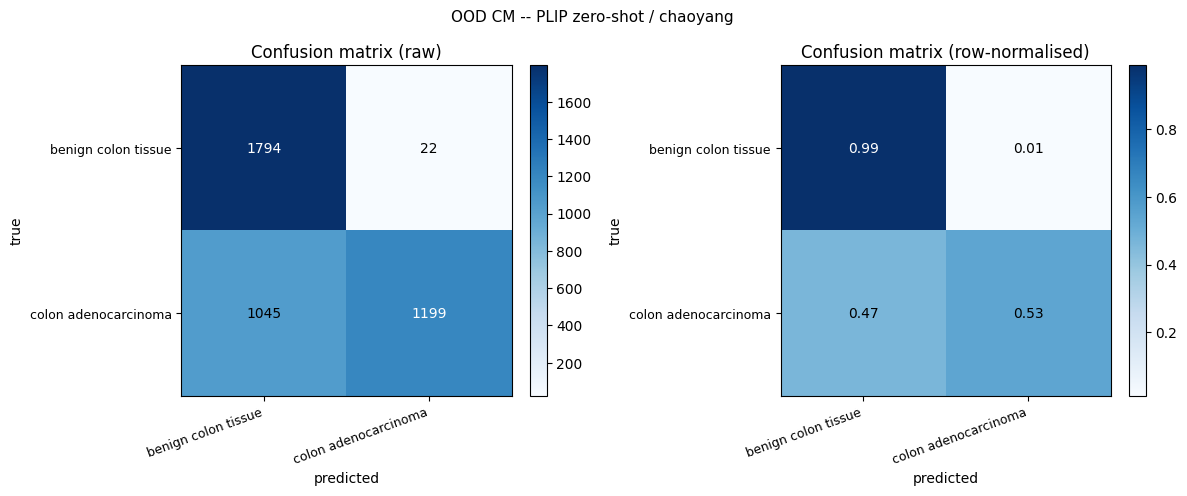

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plip_zeroshot_chaoyang_ood_cm.png


In [10]:
# --- Cell 9: confusion-matrix plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt in [
    (axes[0], cm_raw,  "Confusion matrix (raw)",            "d"),
    (axes[1], cm_norm, "Confusion matrix (row-normalised)", ".2f"),
]:
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(target_names, rotation=20, ha="right", fontsize=9)
    ax.set_yticklabels(target_names, fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"OOD CM -- PLIP zero-shot / {DATASET_TAG}", fontsize=11)
plt.tight_layout()
cm_path = PLOTS_DIR / f"{OUT_TAG}_ood_cm.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {cm_path}")


## 10 — LC25000 reference + shared UMAP fit

The cross-distribution UMAP requires LC25000 reference embeddings encoded
with the **same** PLIP image encoder so the OOD and in-distribution points
share an embedding space. The split is regenerated from the canonical
`lc25000_seed42.json` (or rebuilt deterministically if missing).

In [11]:
# --- Cell 10: LC25000 reference + shared UMAP fit ---
import kagglehub

LC_SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
if LC_SPLIT_PATH.exists():
    lc_split = load_split(LC_SPLIT_PATH)
    print(f"Loaded LC25000 split from {LC_SPLIT_PATH}")
else:
    print("Downloading LC25000 via kagglehub ...")
    lc_dataset_path = kagglehub.dataset_download(
        "andrewmvd/lung-and-colon-cancer-histopathological-images"
    )
    all_paths, all_indices = discover_records(lc_dataset_path)
    lc_split = stratified_split(all_paths, all_indices,
                                val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(lc_split, LC_SPLIT_PATH)

lc_test_paths   = np.asarray(lc_split["test_paths"])
lc_test_indices = np.asarray(lc_split["test_indices"], dtype=np.int32)
print(f"LC25000 test set: {len(lc_test_paths)} images")
for idx in range(len(CLASS_INFO)):
    print(f"  [{idx}] {INDEX_TO_NAME[idx]}: {int((lc_test_indices == idx).sum())}")

lc_target_mask    = np.isin(lc_test_indices, TARGET_LC_IDX)
lc_target_paths   = lc_test_paths[lc_target_mask]
lc_target_indices = lc_test_indices[lc_target_mask]

print(f"\nEncoding {len(lc_test_paths)} LC25000 test images via PLIP ...")
lc_test_features = encode_images(lc_test_paths)
print(f"LC25000 image embeddings: {lc_test_features.shape}")

# Anchor = the 5 class prompt embeddings (already L2-normalised).
anchor_vectors = class_text_embeddings
anchor_kind = "prompt"
print(f"Anchor vectors ({anchor_kind}): {anchor_vectors.shape}")

print(f"\nFitting combined UMAP over {len(lc_test_features) + len(ood_features) + len(anchor_vectors)} points ...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
combined = np.vstack([lc_test_features, ood_features, anchor_vectors])
combined_2d = reducer.fit_transform(combined)

n_lc, n_ood = len(lc_test_features), len(ood_features)
lc_2d         = combined_2d[:n_lc]
ood_2d        = combined_2d[n_lc:n_lc + n_ood]
anchor_2d     = combined_2d[n_lc + n_ood:]
lc_target_2d  = lc_2d[lc_target_mask]
anchor_2d_tgt = anchor_2d[TARGET_LC_IDX]
print(f"  lc_2d={lc_2d.shape}  ood_2d={ood_2d.shape}  anchor_2d={anchor_2d.shape}")


Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
LC25000 test set: 2372 images
  [0] benign lung tissue: 475
  [1] lung adenocarcinoma: 472
  [2] lung squamous cell carcinoma: 473
  [3] benign colon tissue: 477
  [4] colon adenocarcinoma: 475

Encoding 2372 LC25000 test images via PLIP ...
  32/2372 images embedded
  352/2372 images embedded
  672/2372 images embedded
  992/2372 images embedded
  1312/2372 images embedded
  1632/2372 images embedded
  1952/2372 images embedded
  2272/2372 images embedded
LC25000 image embeddings: (2372, 512)
Anchor vectors (prompt): (5, 512)

Fitting combined UMAP over 6437 points ...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  lc_2d=(2372, 2)  ood_2d=(4060, 2)  anchor_2d=(5, 2)


## 11 — 2x3 UMAP grid (scatter + thumbnails)

Same layout as the exp_07 OOD eval notebooks so this plot can be dropped
next to the trained-variant UMAPs without re-styling.

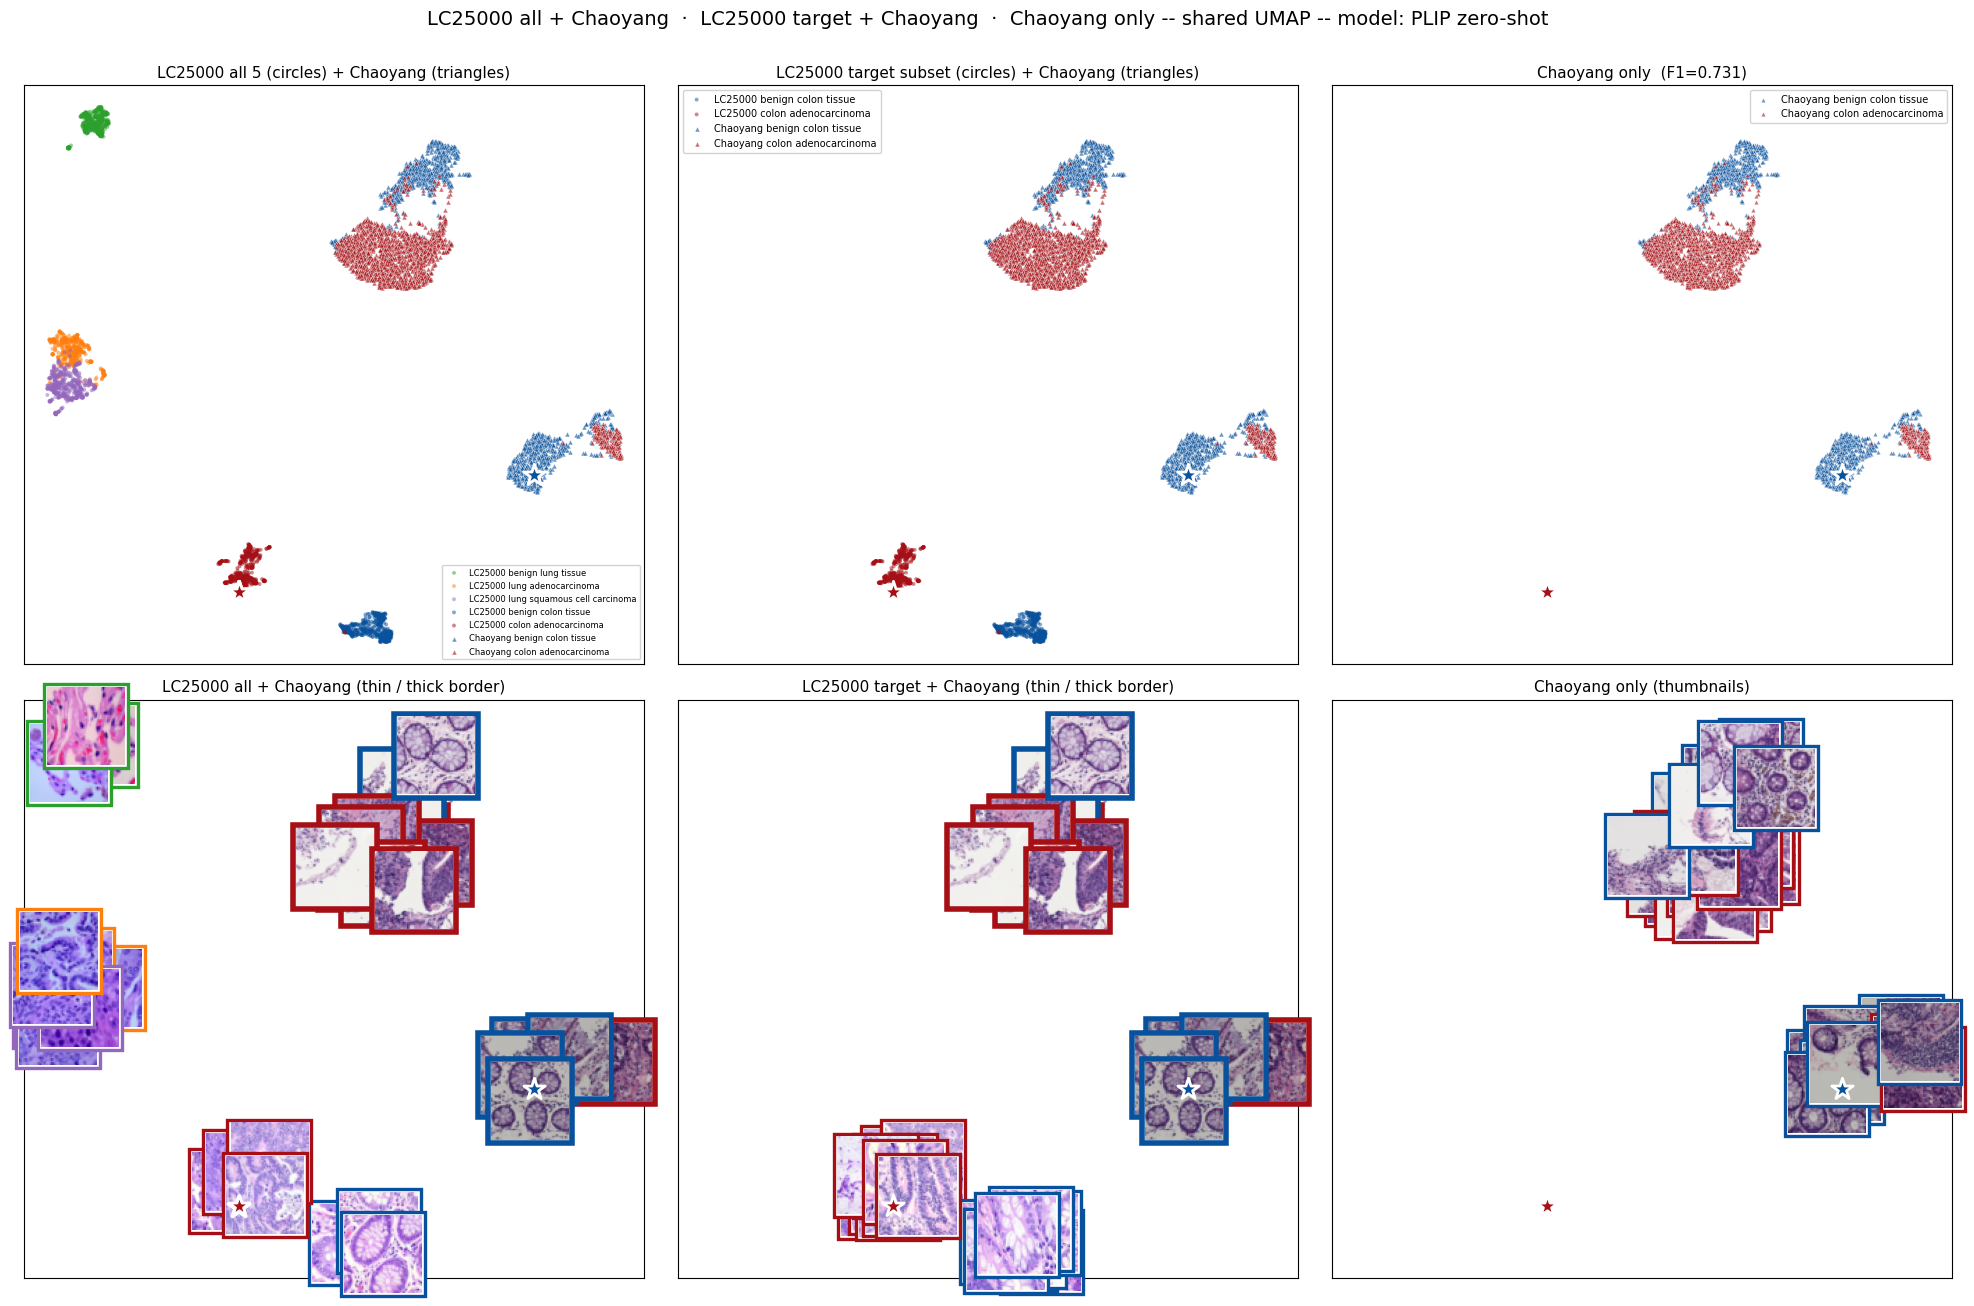

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/plip_zeroshot_chaoyang_ood_umap_grid.png


In [12]:
# --- Cell 11: 2x3 UMAP grid (scatter + thumbnails) ---
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

CLASS_COLOR = {
    0: "#2ca02c",  # benign lung tissue           - green
    1: "#ff7f0e",  # lung adenocarcinoma          - orange
    2: "#9467bd",  # lung squamous cell carcinoma - purple
    3: "#08519c",  # benign colon tissue          - blue
    4: "#a50f15",  # colon adenocarcinoma         - red
}


def draw_anchors(ax, anchor_pos, indices, *, with_labels=False, size=260):
    label_prefix = "prompt"
    for k, idx in enumerate(indices):
        color = CLASS_COLOR[idx]
        ax.scatter(anchor_pos[k, 0], anchor_pos[k, 1], s=size, marker="*",
                   c=color, edgecolors="white", linewidths=2.0, zorder=6)
        if with_labels:
            ax.annotate(f"{label_prefix}:\n{INDEX_TO_NAME[idx]}",
                        (anchor_pos[k, 0], anchor_pos[k, 1]),
                        xytext=(12, 10), textcoords="offset points",
                        fontsize=8, fontweight="bold", zorder=7,
                        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                                  edgecolor=color, alpha=0.9, linewidth=1.5))


def _scatter_ood(ax, alpha=0.55, size=10):
    for idx in sorted(set(ood_lc_indices.tolist())):
        mask = (ood_lc_indices == idx)
        ax.scatter(ood_2d[mask, 0], ood_2d[mask, 1], s=size, alpha=alpha,
                   c=CLASS_COLOR[idx], marker="^",
                   label=f"{OOD_LABEL} {INDEX_TO_NAME[idx]}",
                   edgecolors="white", linewidths=0.3)


def _read_thumb(path, size=(56, 56)):
    try:
        return np.asarray(Image.open(path).convert("RGB").resize(size, Image.BILINEAR))
    except Exception:
        return np.full((size[1], size[0], 3), 200, dtype=np.uint8)


def _layout_thumbnails(ax, coords, paths, class_colors, *, max_thumbs=35,
                       thumb_size=(56, 56), min_dist_frac=0.06, seed=42, border_width=2.4):
    coords = np.asarray(coords)
    rng = np.random.default_rng(seed)
    x_range = float(coords[:, 0].max() - coords[:, 0].min())
    y_range = float(coords[:, 1].max() - coords[:, 1].min())
    min_dist = min_dist_frac * min(x_range, y_range)
    idx = np.arange(len(coords)); rng.shuffle(idx)
    placed = []
    for i in idx:
        x, y = float(coords[i, 0]), float(coords[i, 1])
        if any((x - px) ** 2 + (y - py) ** 2 < min_dist ** 2 for (px, py) in placed):
            continue
        thumb = _read_thumb(paths[i], size=thumb_size)
        ab = AnnotationBbox(OffsetImage(thumb, zoom=1.0), (x, y),
                            frameon=True, pad=0.22,
                            bboxprops=dict(linewidth=border_width, edgecolor=class_colors[i]))
        ax.add_artist(ab)
        placed.append((x, y))
        if len(placed) >= max_thumbs:
            break
    return len(placed)


fig, axes = plt.subplots(2, 3, figsize=(20, 13))

x_min = min(lc_2d[:, 0].min(), ood_2d[:, 0].min(), anchor_2d[:, 0].min())
x_max = max(lc_2d[:, 0].max(), ood_2d[:, 0].max(), anchor_2d[:, 0].max())
y_min = min(lc_2d[:, 1].min(), ood_2d[:, 1].min(), anchor_2d[:, 1].min())
y_max = max(lc_2d[:, 1].max(), ood_2d[:, 1].max(), anchor_2d[:, 1].max())
pad_x = 0.04 * (x_max - x_min); pad_y = 0.04 * (y_max - y_min)
XLIM = (x_min - pad_x, x_max + pad_x); YLIM = (y_min - pad_y, y_max + pad_y)


def _box(ax, title):
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11)


# ROW 1: scatter
ax = axes[0, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o",
               label=f"LC25000 {INDEX_TO_NAME[idx]}", edgecolors="none")
_scatter_ood(ax, alpha=0.6, size=12)
draw_anchors(ax, anchor_2d, list(range(len(CLASS_INFO))))
ax.legend(loc="best", fontsize=6, framealpha=0.85)
_box(ax, f"LC25000 all 5 (circles) + {OOD_LABEL} (triangles)")

ax = axes[0, 1]
for idx in TARGET_LC_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o",
               label=f"LC25000 {INDEX_TO_NAME[idx]}", edgecolors="none")
_scatter_ood(ax, alpha=0.6, size=12)
draw_anchors(ax, anchor_2d_tgt, TARGET_LC_IDX)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_box(ax, f"LC25000 target subset (circles) + {OOD_LABEL} (triangles)")

ax = axes[0, 2]
_scatter_ood(ax, alpha=0.6, size=10)
draw_anchors(ax, anchor_2d_tgt, TARGET_LC_IDX)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_box(ax, f"{OOD_LABEL} only  (F1={macro_f1:.3f})")


# ROW 2: thumbnails
ax = axes[1, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.12, c=CLASS_COLOR[idx], marker="o")
_scatter_ood(ax, alpha=0.18, size=5)
_layout_thumbnails(ax, lc_2d, list(lc_test_paths),
    [CLASS_COLOR[int(lc_test_indices[i])] for i in range(len(lc_test_paths))],
    max_thumbs=25, min_dist_frac=0.07, seed=SEED, border_width=2.4)
_layout_thumbnails(ax, ood_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=15, min_dist_frac=0.07, seed=SEED + 1, border_width=4.0)
draw_anchors(ax, anchor_2d, list(range(len(CLASS_INFO))))
_box(ax, f"LC25000 all + {OOD_LABEL} (thin / thick border)")

ax = axes[1, 1]
for idx in TARGET_LC_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.12, c=CLASS_COLOR[idx], marker="o")
_scatter_ood(ax, alpha=0.18, size=5)
_layout_thumbnails(ax, lc_target_2d, list(lc_target_paths),
    [CLASS_COLOR[int(lc_target_indices[i])] for i in range(len(lc_target_paths))],
    max_thumbs=20, min_dist_frac=0.07, seed=SEED, border_width=2.4)
_layout_thumbnails(ax, ood_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=15, min_dist_frac=0.07, seed=SEED + 1, border_width=4.0)
draw_anchors(ax, anchor_2d_tgt, TARGET_LC_IDX)
_box(ax, f"LC25000 target + {OOD_LABEL} (thin / thick border)")

ax = axes[1, 2]
_scatter_ood(ax, alpha=0.20, size=5)
_layout_thumbnails(ax, ood_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4)
draw_anchors(ax, anchor_2d_tgt, TARGET_LC_IDX)
_box(ax, f"{OOD_LABEL} only (thumbnails)")


fig.suptitle(f"LC25000 all + {OOD_LABEL}  ·  LC25000 target + {OOD_LABEL}  ·  {OOD_LABEL} only "
             f"-- shared UMAP -- model: PLIP zero-shot", fontsize=14, y=1.005)
plt.tight_layout()
p_grid = PLOTS_DIR / f"{OUT_TAG}_ood_umap_grid.png"
fig.savefig(p_grid, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p_grid}")


## Summary

This notebook fills in the two missing cells of the PLIP zero-shot OOD
matrix:

- **NCT-CRC** (close-shift colon) and **LC25000** (in-distribution) are
  already covered by `CLIP_PLIP_zeroshot.ipynb` in this same experiment
  directory.
- This notebook adds **Chaoyang** (different-hospital colon) and
  **LungHist700 20x** (different-organ lung).

Output files use the `plip_zeroshot_<dataset_tag>_ood_*` naming convention,
matching the other rows of the exp_07 OOD eval table (e.g.
`plip_bert_composed_chaoyang_ood_classification.json`,
`baseline_lunghist700_20x_ood_classification.json`).
